In [7]:
from dataclasses import dataclass


@dataclass
class TrolleyProblem:
    n0: int = 3
    n1: int = 1
    ms: int = 1
    m0: int = 0


def U_0(tp: TrolleyProblem):
    return -(tp.n0 / (1 + tp.m0)) - (tp.n1 / (1 + tp.ms + tp.m0))


def U_1(tp: TrolleyProblem):
    return -(tp.n0 / (1 + tp.ms)) - tp.n1


tp = TrolleyProblem(m0=1)
print(U_0(tp))
print(U_1(tp))

-1.8333333333333333
-2.5


/tmp/ipykernel_30083/2866927482.py:14: RuntimeWarning: invalid value encountered in divide
  RHS = numerator / denominator


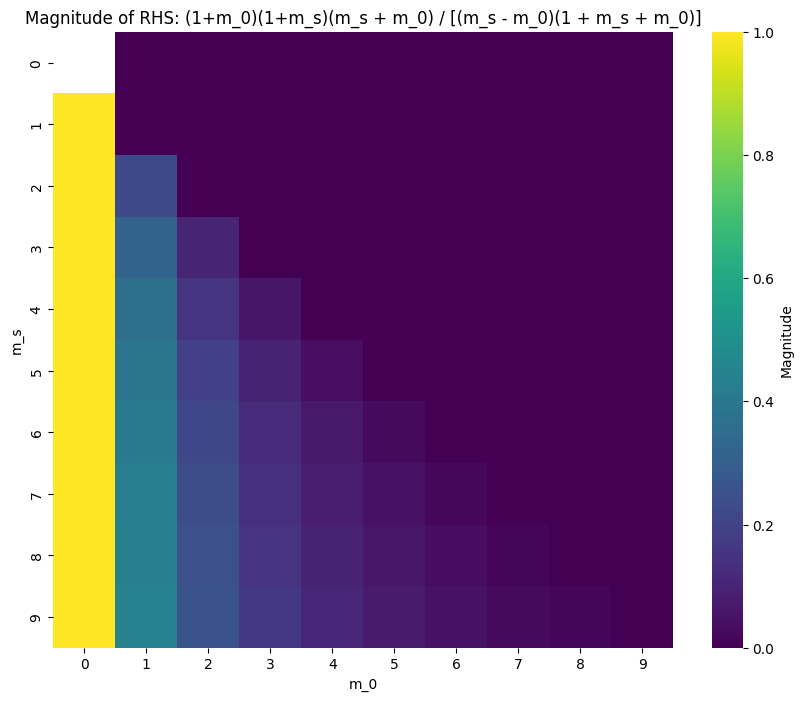

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_rhs_heatmap():
    m_0 = np.arange(10)
    m_s = np.arange(10)
    M_0, M_s = np.meshgrid(m_0, m_s)

    # Compute RHS
    numerator = (M_s - M_0) * (1 + M_s + M_0)
    denominator = (1 + M_0) * (1 + M_s) * (M_s + M_0)
    RHS = numerator / denominator

    # Create mask for m_s == m_0 (undefined)

    plt.figure(figsize=(10, 8))
    sns.heatmap(RHS, cmap="viridis", cbar_kws={"label": "Magnitude"}, vmin=0, vmax=1)
    plt.xlabel("m_0")
    plt.ylabel("m_s")
    plt.title(
        "Magnitude of RHS: (1+m_0)(1+m_s)(m_s + m_0) / [(m_s - m_0)(1 + m_s + m_0)]"
    )
    plt.show()


plot_rhs_heatmap()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider


def plot_quadratic_function_interactive(n0=1.0, n1=0.5, m0=2.0):
    """
    Interactive plot of f(m_s) = A m_s^2 + B m_s + C,
    where:
    A = n0 - n1*(1 + m0)
    B = n0 - n1*(1 + m0)**2
    C = -m0*(1 + m0)*(n0 + n1)
    """
    A = n0 - n1 * (1 + m0)
    B = n0 - n1 * (1 + m0) ** 2
    C = -m0 * (1 + m0) * (n0 + n1)

    # Generate a wide range of m_s values
    m_s = np.linspace(-10, 10, 1000)
    f_ms = A * m_s**2 + B * m_s + C

    # Filter for m_s > -0.5 and f(m_s) > -1
    mask = (m_s > -0.5) & (f_ms > -1)
    m_s_filtered = m_s[mask]
    f_ms_filtered = f_ms[mask]

    plt.figure(figsize=(8, 5))
    plt.plot(
        m_s_filtered,
        f_ms_filtered,
        label=f"f(m_s) = {A:.2f} m_s² + {B:.2f} m_s + {C:.2f}",
    )
    plt.xlabel("m_s")
    plt.ylabel("f(m_s)")
    plt.title("Interactive Quadratic Function Plot (m_s > -0.5, f(m_s) > -1)")
    plt.grid(True)
    plt.legend()
    plt.show()


# Create interactive sliders
interact(
    plot_quadratic_function_interactive,
    n0=FloatSlider(min=0, max=10, step=1, value=1.0, description="n₀"),
    n1=FloatSlider(min=0, max=10, step=1, value=0.5, description="n₁"),
    m0=FloatSlider(min=0, max=10, step=1, value=2.0, description="m₀"),
)

interactive(children=(FloatSlider(value=1.0, description='n₀', max=10.0, step=1.0), FloatSlider(value=0.5, des…

<function __main__.plot_quadratic_function_interactive(n0=1.0, n1=0.5, m0=2.0)>

In [ ]:
x = {"robot": (0, 0), 0: (0, 0)}